This code bootstraps wind data by NEM region

In [1]:
import numpy as np
import pandas as pd, os, datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Statistical analysis
from typing import Sequence, Tuple, Optional
from joblib import Parallel, delayed
from scipy import stats
import math

# Plottting
import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Dask dashboard: /proxy/8787/status


In [2]:
data, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.18 sec
Select group: 0.01 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 0.39 seconds
filter_and_clean: 0.01 seconds
type_conversion_and_dropna: 0.03 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 0.01 seconds
aggregate_hourly: 0.02 seconds
jitter: 0.20 seconds
final_merge: 0.02 seconds
compute: 36.10 seconds
--- END REPORT ---

Process group: 41.04 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MEWF1       236
COOPGWF1    148
WRWF1       146
SAPHWF1     129
MUSSELR1    112
BODWF1       91
GRANWF1      84
MTGELWF1     60
STWF1        58
BALDHWF1     57
LKBONNY2     54
TARALGA1     54
KABANWF1     52
WOODLWN1     50
LKBONNY3     50
HDWF1        48
BOCORWF1     48
HDWF3        48
HDWF2        48
CROOKWF2     48
GULLRWF1     45
LGAPWF1      45
GUNNING1     45
NBHWF1       42
DULAWF1      41
HALLWF1      41
HALLWF2      41
CROWLWF1     40
CRURWF1      39
KIATAWF1     38
CLEMGPWF     38
MACARTH1     37
WATERLWF     36
W

Append clusters to generation timeseries in tidy format

In [3]:
clust_map = info
clust_map

,station_name,participant,technology_type_primary,fuel_source_primary,reg_cap_mw,classification,DUID,station_name_nmap,current_output_mw,region,...,fuel_source_primary_nmap,fuel_source_descriptor,technology_type_primary_nmap,technology_type_descriptor,aggregation,lat,lon,_merge,lat_jittered,lon_jittered
0,Ararat Wind Farm,Ararat Wind Farm Pty Ltd,Wind Turbine - Onshore,Wind,240,SS,ARWF1,Ararat Wind Farm,0.00000,VIC1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-37.238518,143.079431,both,-37.238518,143.079431
1,Bald Hills Wind Farm,Infrastructure Capital Group,Wind Turbine - Onshore,Wind,106.6,SS,BALDHWF1,Bald Hills Wind Farm,33.21600,VIC1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-38.790800,145.927700,both,-38.790800,145.927700
4,Hallett 5 The Bluff WF,Eurus Energy,Wind Turbine - Onshore,Wind,52.5,SS,BLUFF1,The Bluff Wind Farm,0.00000,SA1,...,Wind,Wind,Renewable,Wind - Onshore,N,-33.369331,138.982476,both,-33.369331,138.982476
6,Boco Rock Wind Farm,South Pacific Power Pty Ltd,Wind Turbine - Onshore,Wind,98.6,SS,BOCORWF1,Boco Rock Wind Farm,8.50000,NSW1,...,Wind,Wind,Renewable,Wind - Onshore,N,-36.576955,149.125867,both,-36.620391,149.162712
7,Bodangora Wind Farm,Bodangora Wind Farm Pty Ltd,Wind Turbine - Onshore,Wind,113.19,SS,BODWF1,Bodangora Wind Farm,5.74383,NSW1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-32.414600,149.099795,both,-32.414600,149.099795
11,Bulgana Green Power Hub - Wind Farm,Bulgana Wind Farm Pty Ltd,Wind Turbine - Onshore,Wind,204.4,SS,BULGANA1,Bulgana Green Power Hub,0.00000,VIC1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-37.118103,142.960530,both,-37.118103,142.960530
17,Cherry Tree Wind Farm,Cherry Tree Wind Farm Pty Limited A.T.F. Cherr...,Wind Turbine - Onshore,Wind,57.6,SS,CHYTWF1,Cherry Tree Wind Farm,53.18000,VIC1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-37.099382,145.267835,both,-37.099382,145.267835
18,Clements Gap Wind Farm,Pacific Hydro Clements Gap Pty Ltd,Wind Turbine - Onshore,Wind,56.7,SS,CLEMGPWF,Clements Gap Wind Farm,53.59404,SA1,...,Wind,Wind,Renewable,Wind - Onshore,N,-33.508568,138.119175,both,-33.508568,138.119175
19,Canunda,Canunda Power Pty Ltd,Wind Turbine - Onshore,Wind,46,NS,CNUNDAWF,Canunda Wind Farm,0.10011,SA1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-37.760253,140.403311,both,-37.760253,140.403311
22,Coopers Gap Wind Farm,PARF Company 6 Pty Limited,Wind Turbine - Onshore,Wind,330.33,SS,COOPGWF1,Coopers Gap Wind Farm,13.20000,QLD1,...,Wind,Wind,Renewable,Wind - Onshore,Y,-26.733227,151.472270,both,-26.733227,151.472270


In [4]:
clust_map[clust_map['fuel_source_primary']=='Wind']['region'].isna().sum()

0

In [5]:
df = data.sort_values(['EHF_flag','region','DUID','time'])

Z-score normalise by unit.

In [6]:
df['z_score'] = df.groupby('DUID')['TOTALMWh'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)
df

,DUID,time,TOTALMWh,TOTALCLEARED,AGCSTATUS,lat,lon,tas,EHF_val,HW_EHF_avg,...,tas_3d_avg,tas_3d_peak,event_group,HW_event_day,date,fuel_source_primary,region,lat_jittered,lon_jittered,z_score
363718,BOCORWF1,2019-07-01 00:00:00+00:00,3.149167,3.117167,0,-36.63,149.09,281.625,0.0,NaN,...,NaN,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,NSW1,-36.620391,149.162712,-0.850348
365185,BOCORWF1,2019-07-01 00:00:00+00:00,28.941667,28.914833,0,-36.63,149.09,281.625,0.0,NaN,...,NaN,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,NSW1,-36.620391,149.162712,-0.269557
365186,BOCORWF1,2019-07-01 01:00:00+00:00,31.454166,31.61925,0,-36.63,149.09,281.625,0.0,NaN,...,NaN,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,NSW1,-36.620391,149.162712,-0.21298
365187,BOCORWF1,2019-07-01 02:00:00+00:00,27.259167,27.131833,0,-36.63,149.09,281.625,0.0,NaN,...,NaN,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,NSW1,-36.620391,149.162712,-0.307443
365188,BOCORWF1,2019-07-01 03:00:00+00:00,46.02,46.875167,0,-36.63,149.09,281.625,0.0,NaN,...,NaN,NaN,NaN,NaN,2019-07-01 00:00:00+00:00,Wind,NSW1,-36.620391,149.162712,0.115011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4028914,YENDWF1,2019-06-30 19:00:00+00:00,4.976667,4.938333,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,Wind,VIC1,-37.631438,144.020788,-0.803764
4028915,YENDWF1,2019-06-30 20:00:00+00:00,5.025833,4.981667,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,Wind,VIC1,-37.631438,144.020788,-0.802562
4028916,YENDWF1,2019-06-30 21:00:00+00:00,4.973333,4.953333,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,Wind,VIC1,-37.631438,144.020788,-0.803846
4028917,YENDWF1,2019-06-30 22:00:00+00:00,5.023333,4.990833,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,Wind,VIC1,-37.631438,144.020788,-0.802623


In [7]:
def bootstrap_curve(
    X: np.ndarray,
    n_boot: int,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap mean and median daily curves with confidence intervals, batched for speed and memory.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n_days, n_hours)
    n_boot : int
        Number of bootstrap samples
    batch_size : Optional[int]
        Number of bootstrap samples to process per batch. If None, chosen automatically.
    seed : int
        RNG seed for reproducibility

    Returns
    -------
    mean_curve : np.ndarray, shape (n_hours,)
    mean_lower : np.ndarray, shape (n_hours,)
    mean_upper : np.ndarray, shape (n_hours,)
    median_curve : np.ndarray, shape (n_hours,)
    median_lower : np.ndarray, shape (n_hours,)
    median_upper : np.ndarray, shape (n_hours,)
    """
    n_days, n_hours = X.shape
    curves_mean = np.empty((n_boot, n_hours), dtype=np.float64)
    curves_median = np.empty((n_boot, n_hours), dtype=np.float64)
    rng = np.random.default_rng(seed)

    # Choose a batch size that keeps memory reasonable
    if batch_size is None:
        # Aim for ~50–200 MB peak for the 3D array; adjust as needed
        # Each float64 ~8 bytes -> batch_size * n_days * n_hours * 8 bytes
        target_bytes = 100 * 1024 * 1024  # 100 MB
        approx_bs = max(1, int(target_bytes / (n_days * n_hours * 8)))
        batch_size = min(n_boot, max(100, approx_bs))

    out_start = 0
    while out_start < n_boot:
        k = min(batch_size, n_boot - out_start)
        # Indices: shape (k, n_days)
        idx = rng.integers(0, n_days, size=(k, n_days))
        # Samples: shape (k, n_days, n_hours)
        samples = X[idx]
        # Aggregate across days -> shape (k, n_hours)
        curves_mean[out_start:out_start + k] = samples.mean(axis=1)
        curves_median[out_start:out_start + k] = np.median(samples, axis=1)
        out_start += k

    # Compute mean and 95% CI across bootstrap replicates
    mean_curve = curves_mean.mean(axis=0)
    mean_lower = np.percentile(curves_mean, 2.5, axis=0)
    mean_upper = np.percentile(curves_mean, 97.5, axis=0)

    # Median curve is the median across bootstrap medians
    median_curve = np.median(curves_median, axis=0)
    median_lower = np.percentile(curves_median, 2.5, axis=0)
    median_upper = np.percentile(curves_median, 97.5, axis=0)

    return mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper

In [8]:
def prepare_daily_matrix(
    df: pd.DataFrame,
    value_col: str,
    time_col: str = "time",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a long time series into a (n_days, n_hours) matrix and hour labels.
    Returns:
        X : ndarray shape (n_days, n_hours)
        hours : ndarray of hour labels (e.g. 0..23)
    """
    if df.empty:
        return np.empty((0, 0)), np.array([], dtype=int)

    tmp = df.copy()
    tmp["day"] = tmp[time_col].dt.floor("D")
    tmp["hour"] = tmp[time_col].dt.hour

    daily = (
        tmp.pivot_table(index="day", columns="hour", values=value_col)
           .dropna()
           .sort_index()
    )

    if daily.empty:
        return np.empty((0, 0)), np.array(sorted(tmp["hour"].unique()), dtype=int)

    X = daily.to_numpy()
    hours = daily.columns.to_numpy()
    return X, hours

In [9]:
def bootstrap_group(
    name,
    gdf: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    batch_size: Optional[int] = None,
    seed: int = 42,
):
    """
    Apply bootstrap_curve to a single group.
    Returns:
        group key (name), curves tuple, hour_labels (array)
    """
    X, hour_labels = prepare_daily_matrix(gdf, value_col=value_col, time_col="time")

    # Handle groups with no valid days
    if X.size == 0 or X.shape[0] == 0:
        n_hours = len(hour_labels)
        empty = np.full(n_hours, np.nan)
        return name, (empty, empty, empty, empty, empty, empty), hour_labels

    curves = bootstrap_curve(X, n_boot=n_boot, batch_size=batch_size, seed=seed)
    return name, curves, hour_labels

In [10]:
def _results_to_dataframe(
    results,
    group_cols: Sequence[str],
) -> pd.DataFrame:
    """
    Convert list of (name, curves, hour_labels) into a tidy DataFrame.
    """
    rows = []
    for name, curves, hour_labels in results:
        mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper = curves

        if isinstance(name, tuple):
            key_map = dict(zip(group_cols, name))
        else:
            key_map = {group_cols[0]: name}

        for i, hour in enumerate(hour_labels):
            rows.append(
                {
                    **key_map,
                    "hour": int(hour),
                    "mean": float(mean_curve[i]) if np.isfinite(mean_curve[i]) else np.nan,
                    "mean_lower": float(mean_lower[i]) if np.isfinite(mean_lower[i]) else np.nan,
                    "mean_upper": float(mean_upper[i]) if np.isfinite(mean_upper[i]) else np.nan,
                    "median": float(median_curve[i]) if np.isfinite(median_curve[i]) else np.nan,
                    "median_lower": float(median_lower[i]) if np.isfinite(median_lower[i]) else np.nan,
                    "median_upper": float(median_upper[i]) if np.isfinite(median_upper[i]) else np.nan,
                }
            )
    return pd.DataFrame(rows)

In [11]:
def run_grouped_bootstrap(
    df: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 10000,
    group_cols: Sequence[str] = ("cluster", "DUID", "EHF_flag"),
    parallel: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
    prefer: Optional[str] = None,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    High-level function to compute bootstrapped curves by group.

    Parameters
    ----------
    df : DataFrame
        Must contain `time`, `value_col`, and `group_cols`.
    parallel : bool
        If True, use joblib.Parallel; otherwise run in a single process.
    """
    needed = set(group_cols) | {"time", value_col}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby(list(group_cols), sort=False)

    if parallel:
        tasks = (
            delayed(bootstrap_group)(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        )

        results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(tasks)
    else:
        results = [
            bootstrap_group(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        ]

    return _results_to_dataframe(results, group_cols)

Here is where the grouping, value, and number of bootstraps is specified.

In [12]:
df_results = run_grouped_bootstrap(
    df,
    value_col="z_score",
    n_boot=1000,
    group_cols=("region", "EHF_flag"),
    parallel=True,
    n_jobs=-1,
    backend="loky",
)

In [13]:
df_results = df_results.merge(clust_map[["region"]], on="region", how='left')

In [14]:
df_results

,region,EHF_flag,hour,mean,mean_lower,mean_upper,median,median_lower,median_upper
0,NSW1,0.0,0,0.145614,0.115293,0.176219,0.070143,0.032324,0.103287
1,NSW1,0.0,0,0.145614,0.115293,0.176219,0.070143,0.032324,0.103287
2,NSW1,0.0,0,0.145614,0.115293,0.176219,0.070143,0.032324,0.103287
3,NSW1,0.0,0,0.145614,0.115293,0.176219,0.070143,0.032324,0.103287
4,NSW1,0.0,0,0.145614,0.115293,0.176219,0.070143,0.032324,0.103287
...,...,...,...,...,...,...,...,...,...
2539,VIC1,1.0,23,0.064712,-0.065288,0.190690,-0.006929,-0.143467,0.153904
2540,VIC1,1.0,23,0.064712,-0.065288,0.190690,-0.006929,-0.143467,0.153904
2541,VIC1,1.0,23,0.064712,-0.065288,0.190690,-0.006929,-0.143467,0.153904
2542,VIC1,1.0,23,0.064712,-0.065288,0.190690,-0.006929,-0.143467,0.153904


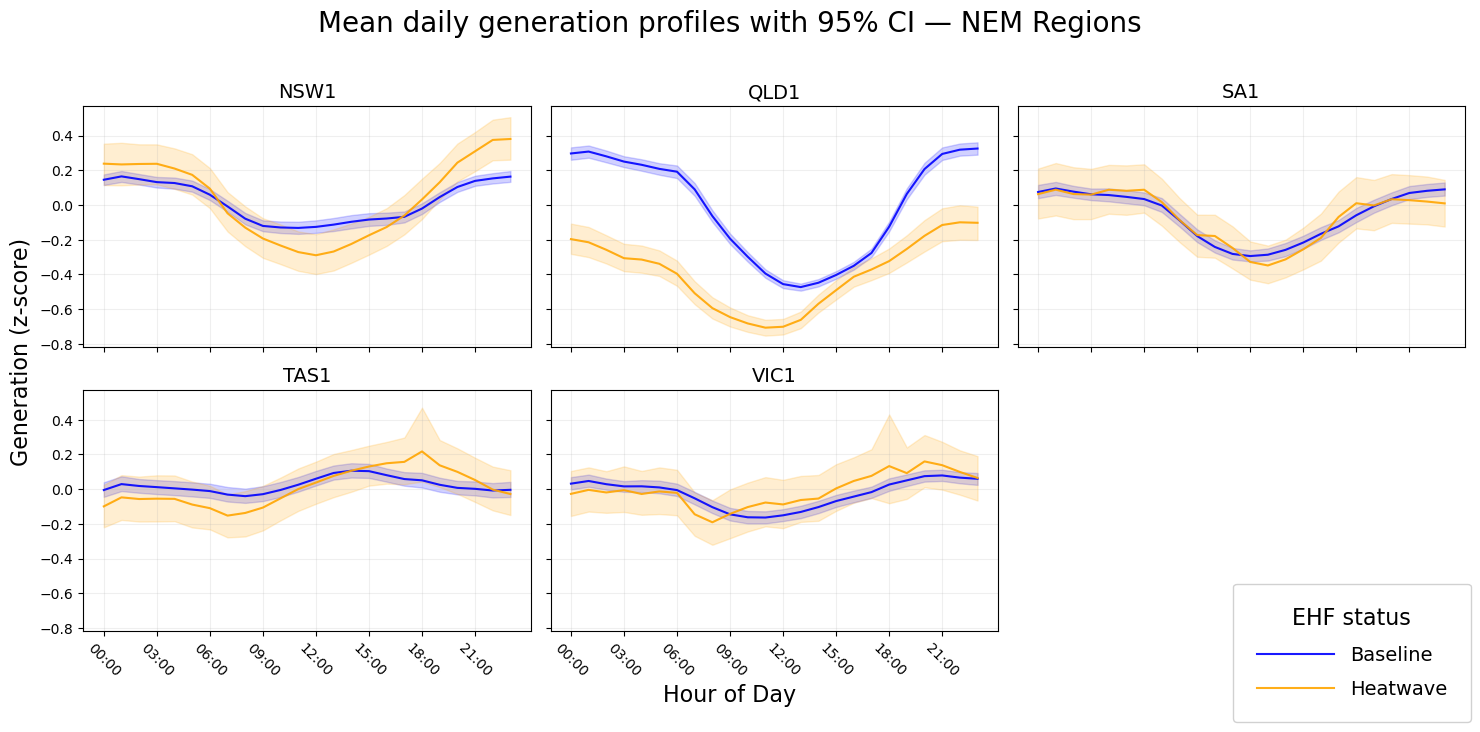

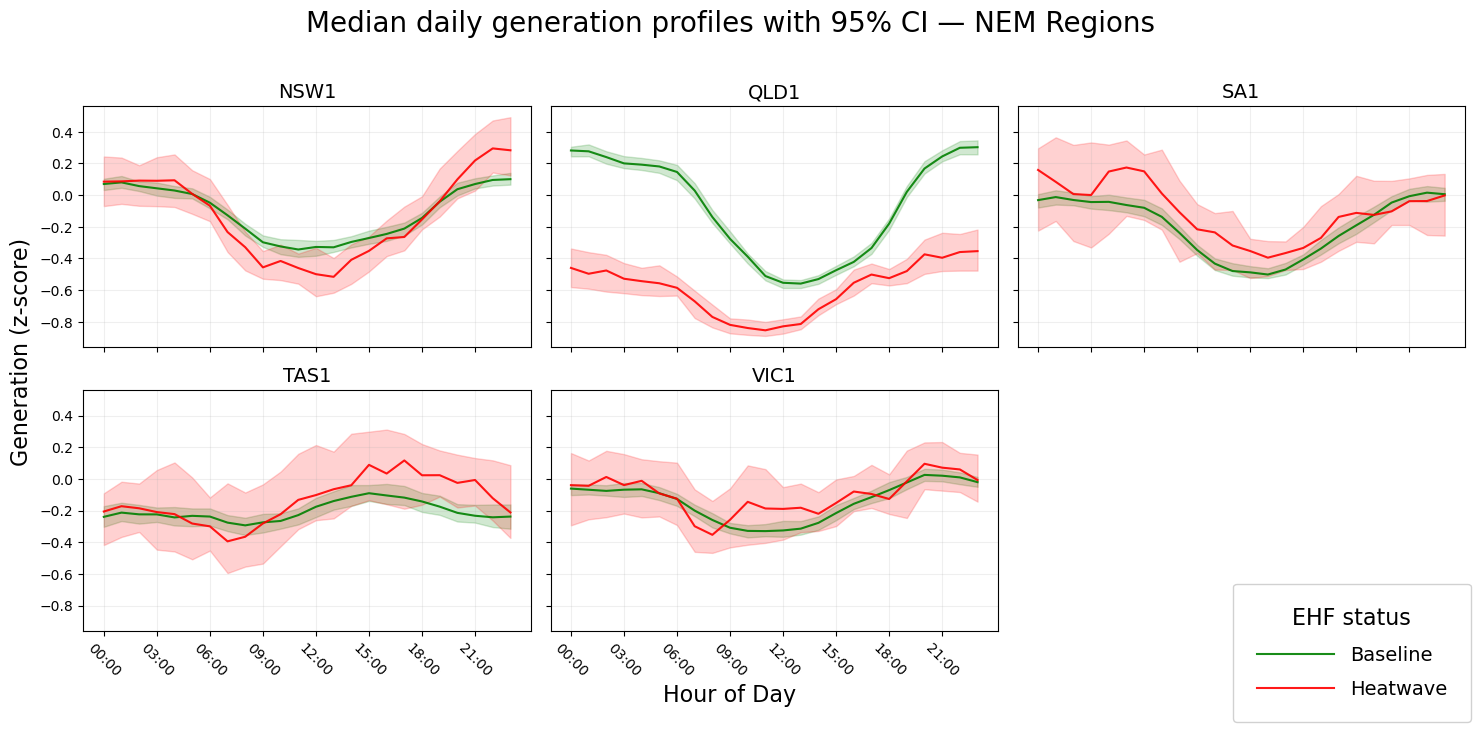

In [17]:
def plot_aggregated_regions_faceted(df_results: pd.DataFrame, metric='mean'):
    """
    Plot mean/median curves with 95% CI for aggregated clusters in a 2x3 faceted layout.
    """

    if metric not in ['mean', 'median']:
        raise ValueError("metric must be 'mean' or 'median'")

    regions = sorted(df_results['region'].unique())
    
    if len(regions) == 0:
        raise ValueError("No regions found in df_results")

    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(5*ncols, 3.8*nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    label_map = {0.0: "Baseline", 1.0: "Heatwave"}
    label_map_int = {0: "Baseline", 1: "Heatwave"}
    colors = ['blue', 'orange'] if metric == "mean" else ['green', 'red']

    hour_ticks = list(range(0,24,3))
    hour_labels = [f"{h:02d}:00" for h in hour_ticks]

    # Plot each aggregated cluster in its own facet
    for ax_idx, cluster in enumerate(regions[:nrows*ncols]):
        ax = axes[ax_idx]
        cdf = df_results[df_results['region'] == cluster].copy()
        hw_statuses = sorted(cdf['EHF_flag'].unique())

        for i, status in enumerate(hw_statuses):
            sdf = cdf[cdf['EHF_flag'] == status].sort_values('hour')

            y = sdf[metric].values
            lower = sdf[f'{metric}_lower'].values
            upper = sdf[f'{metric}_upper'].values

            label = label_map.get(float(status), label_map_int.get(int(status), str(status)))
            ax.plot(sdf['hour'], y, color=colors[i % len(colors)], alpha=0.9, label=label)
            ax.fill_between(sdf['hour'], lower, upper, color=colors[i % len(colors)], alpha=0.18)

        ax.set_title(cluster, fontsize=14)

        ax.set_xticks(hour_ticks)
        ax.set_xticklabels(hour_labels, rotation=315)

        ax.grid(True, alpha=0.2)

    # Remove unused axes
    for ax in axes[len(regions):]:
        ax.remove()

    fig.suptitle(f'{metric.capitalize()} daily generation profiles with 95% CI — NEM Regions', y=0.95, fontsize=20)
    fig.text(0.5, 0.04, 'Hour of Day', ha='center', fontsize=16)
    fig.text(0.02, 0.5, 'Generation (z-score)', va='center', rotation='vertical', fontsize=16)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    if uniq:
        fig.legend(
        [h for h, _ in uniq],
        [l for _, l in uniq],
        title="EHF status",
        loc='lower right',
        # bbox_to_anchor=(1.18, 0.98),
    
        # --- NEW: make legend bigger ---
        prop={'size': 14},         # legend text size
        title_fontsize=16,         # legend title size
    
        # --- NEW: make the panel larger & clearer ---
        frameon=True,              # draw a box around legend
        framealpha=0.9,            # panel transparency
        borderpad=1.2,             # padding inside the panel
        labelspacing=0.8,          # spacing between items
        handlelength=4,          # length of color lines
    )


    plt.tight_layout(rect=[0.03, 0.05, 1, 0.93])
    plt.show()

# Example:
plot_aggregated_regions_faceted(df_results, metric='mean')
plot_aggregated_regions_faceted(df_results, metric='median')
